# L0.2 — Linear Model `y = ax + b`

Hands-on notebook for the lesson [`0-2-linear-model.mdx`](../../llm-quest-theory/level-0/0-2-linear-model.mdx).

> **Learning objectives**
> - See the geometric meaning of `a` (slope) and `b` (intercept).
> - Hand-fit a straight line through data by tuning parameters, using MSE as the yardstick.
> - Understand why MSE uses the squared error.

## Connection to the theory
Covers sections **§2–§6** of the `.mdx`. This notebook is the "hand-fit" version first — lessons [`0-5`](../../llm-quest-theory/level-0/0-5-derivatives.mdx) and `1-2` automate it with gradient descent.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Toy dataset
Simulate "area (x, in hundreds of m^2) vs house price (y, billion VND)" with a linear relation plus Gaussian noise.

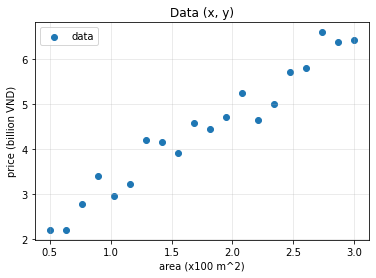

In [2]:
N = 20
x = np.linspace(0.5, 3.0, N)
true_a, true_b = 2.0, 1.0
y = true_a * x + true_b + np.random.normal(0, 0.4, size=N)

plt.scatter(x, y, color="tab:blue", label="data")
plt.xlabel("area (x100 m^2)"); plt.ylabel("price (billion VND)")
plt.title("Data (x, y)"); plt.grid(alpha=0.3); plt.legend(); plt.show()

## 2. Define the model and MSE

$$\hat y = ax + b,\quad \mathrm{MSE}(a,b)=\frac{1}{N}\sum_i(ax_i+b-y_i)^2$$

In [3]:
def predict(x, a, b):
    return a * x + b

def mse(a, b, x=x, y=y):
    return float(np.mean((predict(x, a, b) - y) ** 2))

print("MSE at (a=0, b=0) =", round(mse(0, 0), 3))
print("MSE at (a=2, b=1) =", round(mse(2, 1), 3))

MSE at (a=0, b=0) = 21.384
MSE at (a=2, b=1) = 0.145


## 3. Try 6 different parameter pairs
"Hand-tune" like the slider in the theory. Can you get MSE below 1.0?

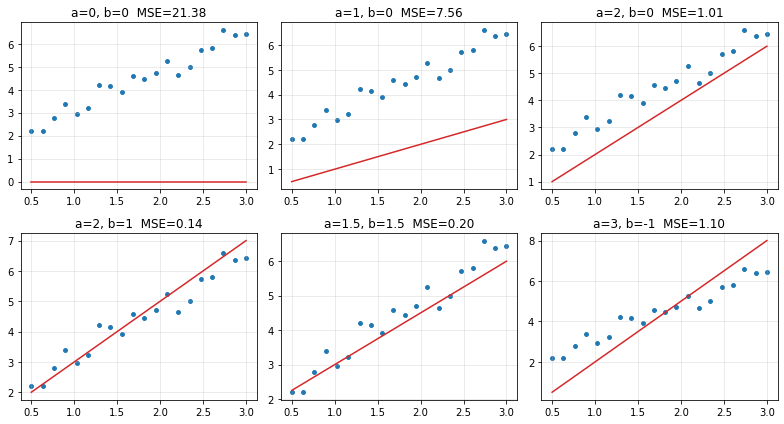

In [4]:
candidates = [(0, 0), (1, 0), (2, 0), (2, 1), (1.5, 1.5), (3, -1)]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, (a, b) in zip(axes.ravel(), candidates):
    ax.scatter(x, y, s=15, color="tab:blue")
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, predict(xs, a, b), color="tab:red")
    ax.set_title(f"a={a}, b={b}  MSE={mse(a,b):.2f}")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Grid search — the "machine" can already find an optimum
No gradient descent yet — just sweep over many `(a, b)` pairs and pick the best.

In [5]:
A = np.linspace(-1, 4, 120)
B = np.linspace(-3, 4, 120)
AA, BB = np.meshgrid(A, B)
# vectorized: (N,) vs (grid, N)
Y_hat = AA[..., None] * x + BB[..., None]   # shape (120, 120, N)
Loss = ((Y_hat - y) ** 2).mean(axis=-1)

best = np.unravel_index(np.argmin(Loss), Loss.shape)
a_star, b_star = AA[best], BB[best]
print(f"Grid optimum: a={a_star:.3f}, b={b_star:.3f}, MSE={Loss[best]:.4f}")
print(f"Ground truth: a={true_a},   b={true_b}")

Grid optimum: a=1.689, b=1.471, MSE=0.0874
Ground truth: a=2.0,   b=1.0


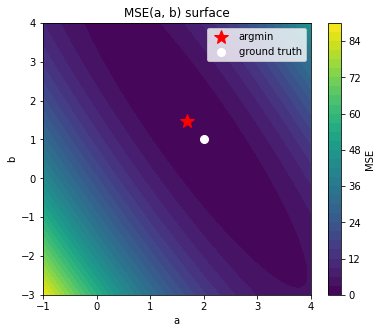

In [6]:
# Visualize the loss surface
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(AA, BB, Loss, levels=30, cmap="viridis")
ax.plot(a_star, b_star, "r*", markersize=14, label="argmin")
ax.plot(true_a, true_b, "wo", markersize=8, label="ground truth")
ax.set_xlabel("a"); ax.set_ylabel("b"); ax.set_title("MSE(a, b) surface")
plt.colorbar(cs, ax=ax, label="MSE"); ax.legend(); plt.show()

## 5. Why squared? — compare with absolute value
Add an outlier to the data and compare MAE vs MSE.

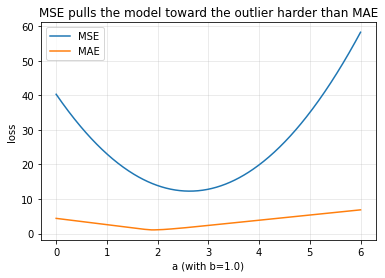

In [7]:
x_out = np.append(x, 3.5)
y_out = np.append(y, 25.0)  # outlier

def mse2(a, b):
    return np.mean((a * x_out + b - y_out) ** 2)

def mae2(a, b):
    return np.mean(np.abs(a * x_out + b - y_out))

aa = np.linspace(0, 6, 400)
fig, ax = plt.subplots()
ax.plot(aa, [mse2(a, 1.0) for a in aa], label="MSE")
ax.plot(aa, [mae2(a, 1.0) for a in aa], label="MAE")
ax.set_xlabel("a (with b=1.0)"); ax.set_ylabel("loss")
ax.set_title("MSE pulls the model toward the outlier harder than MAE")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## 6. Derivative of MSE w.r.t. `a, b`

$$\frac{\partial\mathrm{MSE}}{\partial a}=\frac{2}{N}\sum_i (ax_i+b-y_i)x_i,\qquad \frac{\partial\mathrm{MSE}}{\partial b}=\frac{2}{N}\sum_i (ax_i+b-y_i)$$

These gradients will be the compass for gradient descent in lesson `1-2`.

In [8]:
def grad_mse(a, b):
    err = predict(x, a, b) - y
    da = 2 * np.mean(err * x)
    db = 2 * np.mean(err)
    return da, db

print("grad at (0, 0):", grad_mse(0, 0))
print("grad at ground truth:", grad_mse(true_a, true_b), "-> near zero")

grad at (0, 0): (-17.46433694212636, -8.86296115084654)
grad at ground truth: (0.5882946368210107, 0.13703884915346295) -> near zero


## Reflection questions

1. If we change the loss from `mean((y_hat - y)^2)` to `mean(y_hat - y)` (no square, no absolute value), what behavior would the model prefer?
2. In section 4, why are the contours of `MSE(a, b)` elliptical, not circular?
3. What is the difference between `y = ax + b` and "a single neuron without activation"?

## References
- Source theory: [`0-2-linear-model.mdx`](../../llm-quest-theory/level-0/0-2-linear-model.mdx)
- Next in level-0: [`0-3-vectors`](0-3-vectors.ipynb)